In [1]:
import pandas as pd
import os

PATH_TO_ACS = "Raw_Datasets/ACS"
os.listdir(PATH_TO_ACS)

['ACSDP1Y2010.DP03-2026-04-07T093433.csv',
 'ACSDP1Y2011.DP03-2026-04-07T093240.csv',
 'ACSDP1Y2012.DP03-2026-04-07T093044.csv',
 'ACSDP1Y2013.DP03-2026-04-07T093012.csv',
 'ACSDP1Y2014.DP03-2026-04-07T092823.csv',
 'ACSDP1Y2015.DP03-2026-04-07T092902.csv',
 'ACSDP1Y2016.DP03-2026-04-07T095402.csv',
 'ACSDP1Y2017.DP03-2026-04-07T095501.csv']

In [2]:
acs2010 = pd.read_csv(f'{PATH_TO_ACS}/{os.listdir(PATH_TO_ACS)[0]}')
acs2010snap = acs2010[acs2010['Label (Grouping)'].str.contains("SNAP", na=False)]
acs2010snap

,Label (Grouping),"Baldwin County, Alabama!!Estimate","Baldwin County, Alabama!!Estimate Margin of Error","Baldwin County, Alabama!!Percent","Baldwin County, Alabama!!Percent Margin of Error","Calhoun County, Alabama!!Estimate","Calhoun County, Alabama!!Estimate Margin of Error","Calhoun County, Alabama!!Percent","Calhoun County, Alabama!!Percent Margin of Error","Cullman County, Alabama!!Estimate",...,"Toa Alta Municipio, Puerto Rico!!Percent","Toa Alta Municipio, Puerto Rico!!Percent Margin of Error","Toa Baja Municipio, Puerto Rico!!Estimate","Toa Baja Municipio, Puerto Rico!!Estimate Margin of Error","Toa Baja Municipio, Puerto Rico!!Percent","Toa Baja Municipio, Puerto Rico!!Percent Margin of Error","Trujillo Alto Municipio, Puerto Rico!!Estimate","Trujillo Alto Municipio, Puerto Rico!!Estimate Margin of Error","Trujillo Alto Municipio, Puerto Rico!!Percent","Trujillo Alto Municipio, Puerto Rico!!Percent Margin of Error"
79,With Food Stamp/SNAP benefits in the past ...,"5,951","±1,271",8.7%,±1.7,"8,766","±1,234",19.1%,±2.7,"4,236",...,29.6%,±4.9,"9,584","±1,288",29.4%,±4.1,"5,996","±1,028",23.0%,±3.8


In [3]:
def create_year_table(name):
    year = int(name[7:11:])
    acs = pd.read_csv(f'{PATH_TO_ACS}/{name}')
    df = acs[acs['Label (Grouping)'].str.contains("SNAP", na=False)]
    pct_cols = df.columns[3::4]
    row = df.iloc[0]
    state_map = {
        "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
        "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
        "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
        "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
        "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
        "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
        "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
        "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
        "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
        "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
        "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
        "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
        "Wisconsin": "WI", "Wyoming": "WY", "District of Columbia":"DC", "Puerto Rico":"PRIC"
    }
    records = []
    for col in pct_cols:
        val = row[col]
        name = col.split("!!")[0]
        county, state_full = [x.strip() for x in name.split(",")]
        records.append({
            "State": state_map[state_full],
            "Name": county,
            "SNAP": float(str(val).replace('%', ''))
        })

    final_df = pd.DataFrame(records)
    final_df["Year"] = year-2000
    return final_df

In [4]:
tables = [create_year_table(name) for name in os.listdir(PATH_TO_ACS)]

In [5]:
final_snap_table = pd.concat(tables)
final_snap_table

,State,Name,SNAP,Year
0,AL,Baldwin County,8.7,10
1,AL,Calhoun County,19.1,10
2,AL,Cullman County,14.3,10
3,AL,DeKalb County,16.0,10
4,AL,Elmore County,8.5,10
...,...,...,...,...
832,PRIC,Ponce Municipio,48.3,17
833,PRIC,San Juan Municipio,27.4,17
834,PRIC,Toa Alta Municipio,31.1,17
835,PRIC,Toa Baja Municipio,24.7,17


In [6]:
final_snap_table.to_csv("Cleaned_Datasets/SNAP.csv", index=False)

In [9]:
empirical_treatment_distribution = final_snap_table[final_snap_table["Year"] < 2013].groupby(["State", "Name"]).mean()
empirical_treatment_distribution

SNAP  Year
State Name                                       
AK    Anchorage Municipality         8.7875  13.5
      Fairbanks North Star Borough   6.9375  13.5
      Matanuska-Susitna Borough     10.1625  13.5
AL    Baldwin County                 8.7375  13.5
      Calhoun County                19.1250  13.5
...                                     ...   ...
WV    Monongalia County              7.9250  13.5
      Raleigh County                19.1375  13.5
      Wood County                   16.3875  13.5
WY    Laramie County                 7.8000  13.5
      Natrona County                 7.0500  13.5

[840 rows x 2 columns]

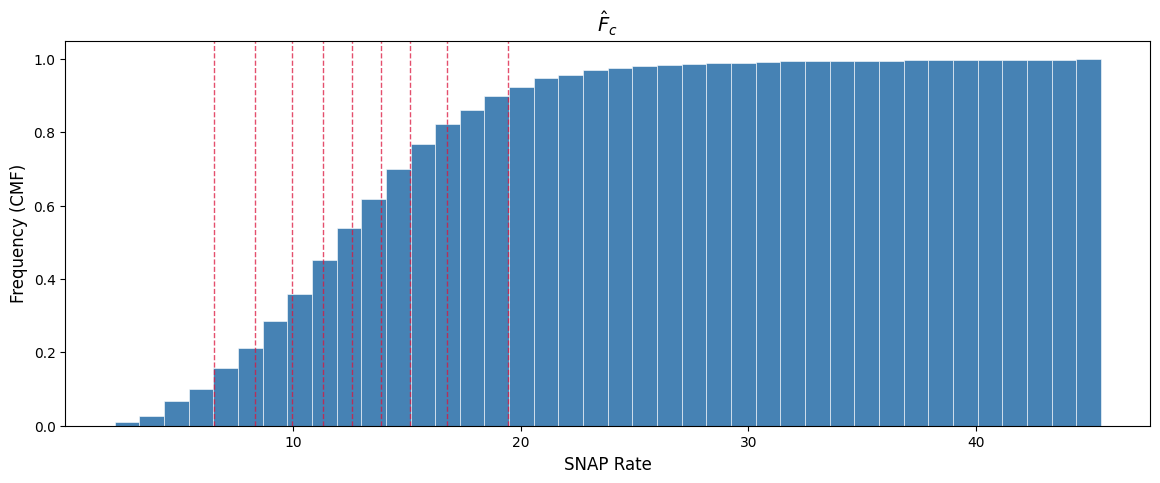

In [14]:
import matplotlib.pyplot as plt
import numpy as np

snap_data = empirical_treatment_distribution["SNAP"]
quantiles = np.quantile(snap_data, np.arange(0.1, 1.0, 0.1))
fig, ax = plt.subplots(figsize=(14, 5))

ax.hist(snap_data, bins=40, density=True, cumulative=True, color="steelblue", edgecolor="white", linewidth=0.4)
for q in quantiles:
    ax.axvline(q, color="crimson", linestyle="--", linewidth=1.0, alpha=0.75)


ax.set_xlabel("SNAP Rate", fontsize=12)
ax.set_ylabel("Frequency (CMF)", fontsize=12)
ax.set_title(r"$\hat{F}_c$", fontsize=14)
plt.show()